In [56]:
## import modules
from sympy import *
from sympy.physics.mechanics import *
init_vprinting()

In [57]:
## define System Variables
m,g,k,l0,t=symbols('m,g,k,l0,t')

#Dynamic Symbols
theta, lt=dynamicsymbols("theta,lt")

#take derivatives
theta_dot=diff(theta,t,1)
theta_ddot=diff(theta,t,2)
lt_dot=diff(lt,t,1)
lt_ddot=diff(lt,t,2)

# define the Kinetic and potential energy and Lagrangian
T=0.5*m*((((l0+lt)**2 )*(theta_dot**2))+ (lt_dot**2))
V= (0.5*k*(((l0+lt)*cos(theta))**2))-(m*g*(l0+lt)*cos(theta))
L=T-V

## Define the poem of classical Mechanics
eq1=diff(diff(L,lt_dot),t) - diff(L,lt)
eq2=diff(diff(L,theta_dot),t) - diff(L,theta)
solns=solve([eq1,eq2],[lt_ddot,theta_ddot])

## show Solution
f=Matrix([theta_dot,solns[theta_ddot],lt_dot,solns[lt_ddot]]) ## 
f_simplify=simplify(f)
x=Matrix([theta,theta_dot,lt,lt_dot])
x_dot=diff(x,t)

Eq(x_dot,f_simplify)

       ⎡                             θ̇                              ⎤
       ⎢                                                            ⎥
       ⎢                k⋅l₀⋅sin(2⋅θ)   k⋅lt⋅sin(2⋅θ)               ⎥
       ⎢  -g⋅m⋅sin(θ) + ───────────── + ───────────── - 2.0⋅m⋅lṫ⋅θ̇  ⎥
⎡θ̇ ⎤   ⎢                      2               2                     ⎥
⎢  ⎥   ⎢  ────────────────────────────────────────────────────────  ⎥
⎢θ̈ ⎥   ⎢                        m⋅(l₀ + lt)                         ⎥
⎢  ⎥ = ⎢                                                            ⎥
⎢lṫ⎥   ⎢                             lṫ                             ⎥
⎢  ⎥   ⎢                                                            ⎥
⎣lẗ⎦   ⎢          2              2        ⎛               2       2⎞⎥
       ⎢- k⋅l₀⋅cos (θ) - k⋅lt⋅cos (θ) + m⋅⎝g⋅cos(θ) + l₀⋅θ̇  + lt⋅θ̇ ⎠⎥
       ⎢────────────────────────────────────────────────────────────⎥
       ⎣                             m                              ⎦

In [58]:
g=f_simplify.subs({theta:'theta',theta_dot:'theta_dot',lt:'lt',lt_dot:'lt_dot'})
for i in range(4):
    print('f[{}]={}'.format(i,g[i]))

f[0]=theta_dot
f[1]=(-g*m*sin(theta) + k*l0*sin(2*theta)/2 + k*lt*sin(2*theta)/2 - 2.0*lt_dot*m*theta_dot)/(m*(l0 + lt))
f[2]=lt_dot
f[3]=(-k*l0*cos(theta)**2 - k*lt*cos(theta)**2 + m*(g*cos(theta) + l0*theta_dot**2 + lt*theta_dot**2))/m


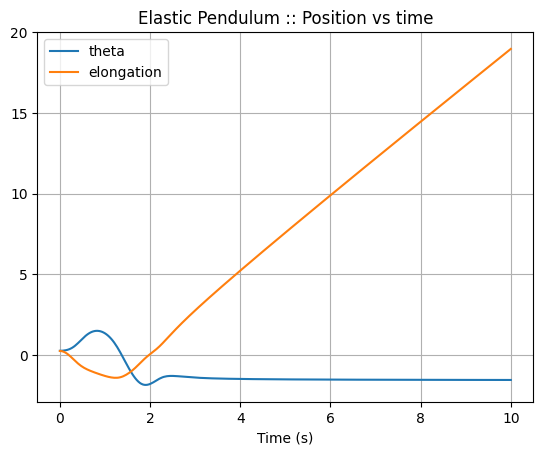

In [59]:
##Import Modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##Define Constants
g=9.81
k=20
m=1
l0=1

x0=np.array([np.deg2rad(15),0,0.25,0])

##define the function
def spring_mass_ode(t,y):
    theta=y[0]
    theta_dot=y[1]
    lt=y[2]
    lt_dot=y[3]
    return (
        theta_dot,
        -g*m*np.sin(theta) + k*l0*np.sin(2*theta)/2 + k*lt*np.sin(2*theta)/2 - 2.0*lt_dot*m*theta_dot/m*(l0 + lt),
        lt_dot,
        -k*l0*np.cos(theta)**2 - k*lt*np.cos(theta)**2 + m*(g*np.cos(theta) + l0*theta_dot**2 + lt*theta_dot**2)/m 
    )

## solve 
sol = solve_ivp(spring_mass_ode,[0,10],x0,t_eval=np.linspace(0,10,10*30))

##output
theta=sol.y[0]
lt=sol.y[2]
t=sol.t

#plot theta and lt vs time
plt.plot(t,theta,label="theta")
plt.plot(t,lt,label="elongation")
plt.legend()
plt.grid()
plt.xlabel("Time (s)")
plt.title("Elastic Pendulum :: Position vs time")
plt.show()